# Variáveis Aleatórias Multidimensionais

#### Intuição

Até agora, analisamos uma única variável aleatória.  
Agora, analisamos múltiplos resultados simultaneamente:

$$
\mathbf{X} = (X, Y)
$$

Exemplo:
- Chuva (X)
- Temperatura (Y)

A distribuição conjunta pode ser vista como um “morro”:

- Base: valores $(x, y)$  
- Altura: densidade $f(x,y)$  

#### Visualização Intuitiva

A distribuição conjunta pode ser interpretada como:

- Centro → distribuição conjunta  
- Eixos → distribuições marginais  

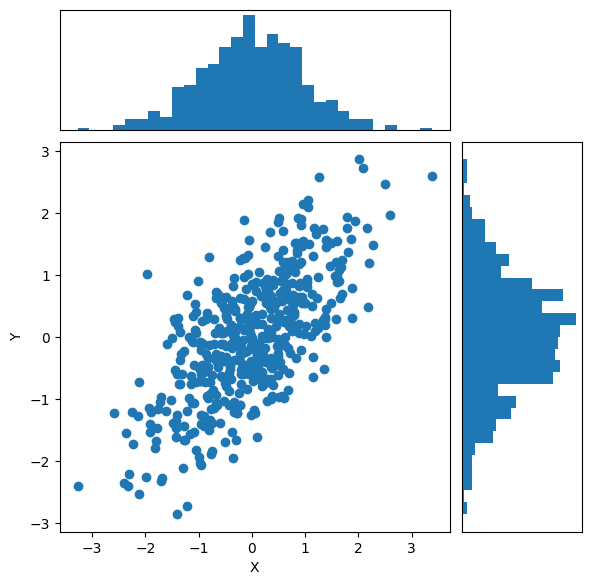

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

mean = [0, 0]
cov = [[1, 0.7], [0.7, 1]]

data = np.random.multivariate_normal(mean, cov, 500)

x = data[:, 0]
y = data[:, 1]

fig = plt.figure(figsize=(6,6))

# Scatter (conjunta)
ax_scatter = plt.axes([0.1, 0.1, 0.65, 0.65])
ax_scatter.scatter(x, y)
ax_scatter.set_xlabel("X")
ax_scatter.set_ylabel("Y")
ax_scatter.set_title("Distribuição Conjunta e Marginais", pad=20)

# Marginal X
ax_histx = plt.axes([0.1, 0.77, 0.65, 0.2])
ax_histx.hist(x, bins=30)
ax_histx.set_xticks([])
ax_histx.set_yticks([])

# Marginal Y
ax_histy = plt.axes([0.77, 0.1, 0.2, 0.65])
ax_histy.hist(y, bins=30, orientation='horizontal')
ax_histy.set_xticks([])
ax_histy.set_yticks([])

plt.show()

### Distribuição Conjunta

#### Discreta
$$
P(X = x, Y = y)
$$

#### Contínua
$$
f(x,y)
$$

#### Distribuições Marginais

As marginais são as “sombras” do gráfico.

$$
f_X(x) = \int f(x,y) dy
$$

$$
f_Y(y) = \int f(x,y) dx
$$

#### Distribuição Condicional

Fixamos uma variável e analisamos a outra:

$$
f(x \mid y) = \frac{f(x,y)}{f_Y(y)}
$$

Interpretação:
"Qual o comportamento de X dado Y?"

#### Independência

$$
f(x,y) = f_X(x) f_Y(y)
$$

Se isso não for verdade → existe dependência

#### Covariância e Correlação

$$
\mathrm{Cov}(X,Y)
$$

$$
\rho = \frac{\mathrm{Cov}(X,Y)}{\sigma_X \sigma_Y}
$$

#### **Dados Correlacionados**

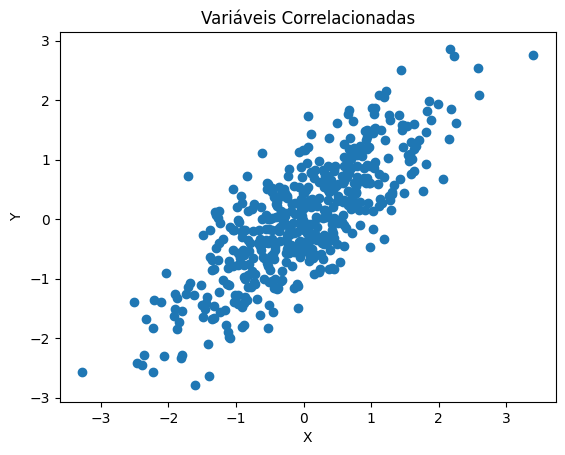

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

mean = [0, 0]
cov = [[1, 0.8],
       [0.8, 1]]

data = np.random.multivariate_normal(mean, cov, 500)

x = data[:, 0]
y = data[:, 1]

plt.scatter(x, y)
plt.title("Variáveis Correlacionadas")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

#### **Distribuição Normal Multivariada (Contour)**

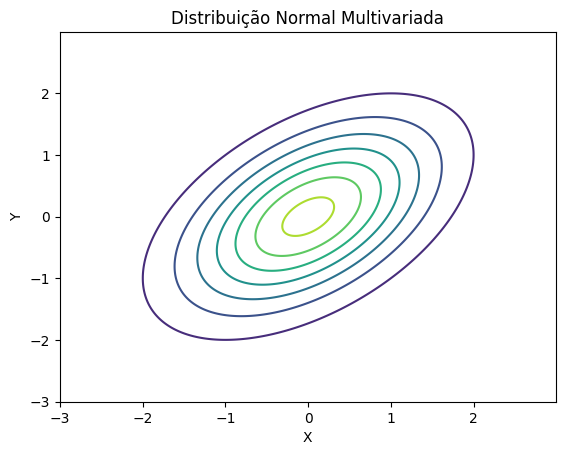

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

x, y = np.mgrid[-3:3:.01, -3:3:.01]
pos = np.dstack((x, y))

rv = multivariate_normal([0, 0], [[1, 0.5], [0.5, 1]])

plt.contour(x, y, rv.pdf(pos))
plt.title("Distribuição Normal Multivariada")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

A tabela abaixo resume como os conceitos estatísticos estudados se conectam diretamente com Machine Learning:

| Conceito Estatístico        | Em Machine Learning                     |
|----------------------------|----------------------------------------|
| Distribuição conjunta       | Estrutura dos dados                    |
| Covariância                 | Relação entre features                 |
| Correlação                  | Dependência entre variáveis            |
| Normal multivariada         | Modelo probabilístico                  |
| Distribuições marginais     | Features individuais                   |
| Distribuição condicional    | Predição: $P(Y \mid X)$                |

#### Conexão com Machine Learning

Até aqui, estudamos distribuições para **uma única variável aleatória**.  
No entanto, problemas reais envolvem **múltiplas variáveis simultaneamente**:

$$
\mathbf{X} = (X_1, X_2, \dots, X_n)
$$

Essas variáveis correspondem às **features** em um dataset.

---

#### Ideia central

Machine Learning busca modelar relações entre variáveis, ou seja:

$$
P(Y \mid X)
$$

Onde:
- $X$ → conjunto de variáveis (multidimensional)
- $Y$ → variável alvo

---

#### Conexão com conceitos anteriores

- **Distribuição conjunta** $P(X, Y)$ → descreve o comportamento completo dos dados  
- **Distribuições marginais** $P(X)$ → analisam variáveis individualmente  
- **Distribuição condicional** $P(Y \mid X)$ → base da predição em ML  

---

#### Interpretação prática

- Variável aleatória → feature  
- Multivariada → dataset com várias features  
- Covariância / Correlação → relação entre variáveis  
- Condicional → previsão do modelo  


Distribuições multivariadas são a base matemática para representar datasets e entender como variáveis se relacionam, sendo fundamentais para a construção de modelos de Machine Learning.


#### **Exemplo Prático: Previsão de Compra**

Considere um dataset com duas variáveis:

- $X_1$ = idade  
- $X_2$ = renda  
- $Y$ = comprou (1) ou não (0)

#### Dados

| Idade | Renda | Compra |
|------|------|--------|
| 25   | 3000 | 0      |
| 30   | 4000 | 0      |
| 40   | 8000 | 1      |
| 50   | 9000 | 1      |

#### Interpretação

Agora temos uma variável multidimensional:

$$
\mathbf{X} = (X_1, X_2) = (\text{idade}, \text{renda})
$$

#### O que o Machine Learning faz

O objetivo é aprender:

$$
P(Y = 1 \mid X_1, X_2)
$$

Ou seja:

> Qual a probabilidade de um cliente comprar dado idade e renda?

#### Conexão com os conceitos

- **Distribuição conjunta**:
$$
P(X_1, X_2, Y)
$$

- **Marginal**:
$$
P(X_1, X_2)
$$

- **Condicional (ML)**:
$$
P(Y \mid X_1, X_2)
$$

#### Intuição

- Pessoas com maior renda → maior chance de compra  
- Existe relação entre as variáveis  
- O modelo aprende esse padrão  


Machine Learning usa variáveis multidimensionais para aprender padrões e fazer previsões baseadas na relação entre elas.